In [4]:
import logging
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from scipy import stats

In [5]:
# prompt: mount google drive in this ipynb

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# prompt: write code to unzip data and save it in drive

import zipfile
import os

# Define the path to the zip file in your Google Drive
zip_file_path = '/content/drive/MyDrive/FYP/data/data.zip'  # Replace with your actual path

# Define the directory where you want to extract the data
extract_path = '/content/drive/My Drive/FYP/data/unzipped' # Replace with your desired path

# Create the extract directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

try:
  with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
  print(f'Successfully unzipped {zip_file_path} to {extract_path}')
except FileNotFoundError:
  print(f'Error: Zip file not found at {zip_file_path}')
except Exception as e:
  print(f'An error occurred: {e}')

Successfully unzipped /content/drive/MyDrive/FYP/data/data.zip to /content/drive/My Drive/FYP/data/unzipped


In [7]:
def get_train(*args):
    """Get training dataset for KDD 10 percent"""
    return _get_adapted_dataset("train")

In [8]:
def get_test(*args):
    """Get testing dataset for KDD 10 percent"""
    return _get_adapted_dataset("test")

In [9]:
def get_shape_input():
    """Get shape of the dataset for KDD 10 percent"""
    return (None, 121)

In [10]:
def get_shape_label():
    """Get shape of the labels in KDD 10 percent"""
    return (None,)

In [11]:
def _get_dataset():
    """ Gets the basic dataset
    Returns :
            dataset (dict): containing the data
                dataset['x_train'] (np.array): training images shape
                (?, 120)
                dataset['y_train'] (np.array): training labels shape
                (?,)
                dataset['x_test'] (np.array): testing images shape
                (?, 120)
                dataset['y_test'] (np.array): testing labels shape
                (?,)
    """
    col_names = _col_names()
    df = pd.read_csv("/content/drive/MyDrive/FYP/data/kddcup.data_10_percent_corrected", header=None, names=col_names)

    text_l = ['protocol_type', 'service', 'flag', 'land', 'logged_in', 'is_host_login', 'is_guest_login']

    for name in text_l:
        _encode_text_dummy(df, name)

    labels = df['label'].copy()
    # Given the ratio of normal(less) and abnormal samples(more), suppose preponderant samples are normal
    # Isolation Tree regards the dominant labels as 1(normal), and the less as -1(abnormal)
    labels[labels != 'normal.'] = 1
    labels[labels == 'normal.'] = -1

    df['label'] = labels

    df_train = df.sample(frac=0.5, random_state=42)
    df_test = df.loc[~df.index.isin(df_train.index)]

    x_train, y_train = _to_xy(df_train, target='label')
    y_train = y_train.flatten().astype(int)
    x_test, y_test = _to_xy(df_test, target='label')
    y_test = y_test.flatten().astype(int)

    # x_train = x_train[y_train != 1]
    # y_train = y_train[y_train != 1]

    scaler = MinMaxScaler()
    scaler.fit(x_train)
    scaler.transform(x_train)
    scaler.transform(x_test)

    dataset = {}
    dataset['x_train'] = x_train.astype(np.float32)
    dataset['y_train'] = y_train.astype(np.float32)
    dataset['x_test'] = x_test.astype(np.float32)
    dataset['y_test'] = y_test.astype(np.float32)

    return dataset

In [12]:
def _get_adapted_dataset(split):
    """ Gets the adapted dataset for the experiments

    Args :
            split (str): train or test
    Returns :
            (tuple): <training, testing> images and labels
    """
    dataset = _get_dataset()
    key_img = 'x_' + split
    key_lbl = 'y_' + split

    if split != 'train':
        dataset[key_img], dataset[key_lbl] = _adapt(dataset[key_img],
                                                    dataset[key_lbl])

    return (dataset[key_img], dataset[key_lbl])

In [13]:
def _encode_text_dummy(df, name):
    """Encode text values to dummy variables(i.e. [1,0,0],[0,1,0],[0,0,1]
    for red,green,blue)
    """
    dummies = pd.get_dummies(df.loc[:,name])
    for x in dummies.columns:
        dummy_name = "{}-{}".format(name, x)
        df.loc[:, dummy_name] = dummies[x]
    df.drop(name, axis=1, inplace=True)

In [14]:
def _to_xy(df, target):
    """Converts a Pandas dataframe to the x,y inputs that TensorFlow needs"""
    result = []
    for x in df.columns:
        if x != target:
            result.append(x)
    dummies = df[target]
    return df.to_numpy().astype(np.float32), dummies.to_numpy().astype(np.float32)

In [15]:
def _col_names():
    """Column names of the dataframe 42-dim"""
    return ["duration","protocol_type","service","flag","src_bytes",
    "dst_bytes","land","wrong_fragment","urgent","hot","num_failed_logins",
    "logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label"]

In [16]:
def _adapt(x, y, rho=0.1):
    """Adapt the ratio of normal/anomalous data"""

    # Normal data: label =0, anomalous data: label =1

    rng = np.random.RandomState(42) # seed shuffling

    inliersx = x[y == 1]
    inliersy = y[y == 1]
    outliersx = x[y == -1]
    outliersy = y[y == -1]

    size_outliers = outliersx.shape[0]
    inds = rng.permutation(size_outliers)
    outliersx, outliersy = outliersx[inds], outliersy[inds]

    size_test = inliersx.shape[0]
    out_size_test = int(size_test*rho/(1-rho))
    outestx = outliersx[:out_size_test]
    outesty = outliersy[:out_size_test]

    testx = np.concatenate((inliersx,outestx), axis=0)
    testy = np.concatenate((inliersy,outesty), axis=0)

    size_test = testx.shape[0]
    inds = rng.permutation(size_test)
    testx, testy = testx[inds], testy[inds]

    return testx, testy

In [17]:
trainx, trainy = get_train()
testx, testy = get_test()

In [18]:
clf = IsolationForest(max_samples=trainx.shape[0], contamination=0.1, random_state=np.random.RandomState(42))
clf.fit(trainx)

IsolationForest(contamination=0.1, max_samples=247010,
                random_state=RandomState(MT19937) at 0x7E995525BE40)

In [19]:
y_pred = clf.predict(testx)

In [20]:
import joblib

# Save the trained model to a file
joblib.dump(clf, 'isolation_forest.joblib')

['isolation_forest.joblib']

In [21]:
print(testy.shape,y_pred.shape)
print('testy -1:',(testy == -1).sum())
print('y_pred -1:',(y_pred == -1).sum())
posi_num = 0

for i in range(0, len(testy)):
    if testy[i] == y_pred[i] and testy[i] == -1:
        posi_num += 1
print('posi_num', posi_num)
n_errors = (y_pred != testy).sum()

print("Total errors:", n_errors, "Accuracy:", 1 - n_errors / testx.shape[0], 'Precision:', posi_num / (y_pred == -1).sum())

(220424,) (220424,)
testy -1: 22042
y_pred -1: 15636
posi_num 7742
Total errors: 22194 Accuracy: 0.8993122346024026 Precision: 0.4951394218470197


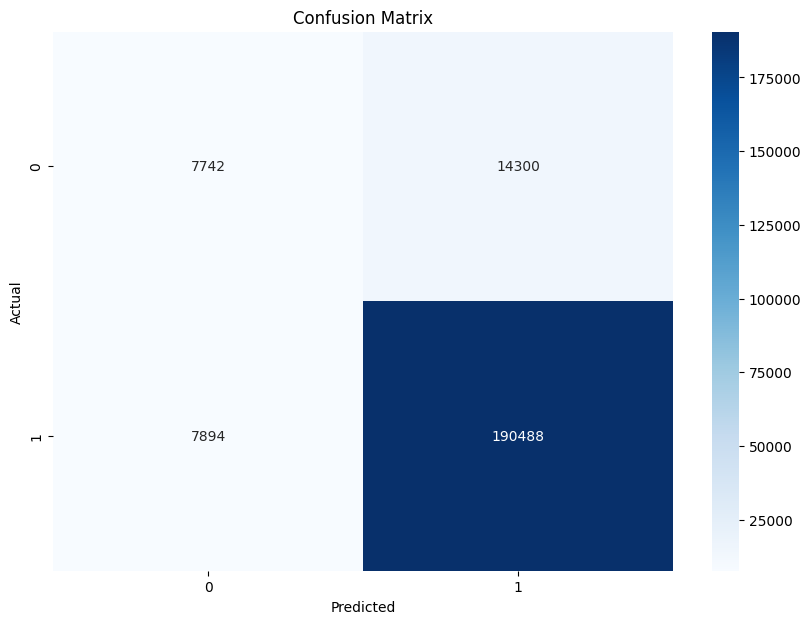

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming y_true are the true labels and y_pred are the predicted labels
conf_matrix = confusion_matrix(testy, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


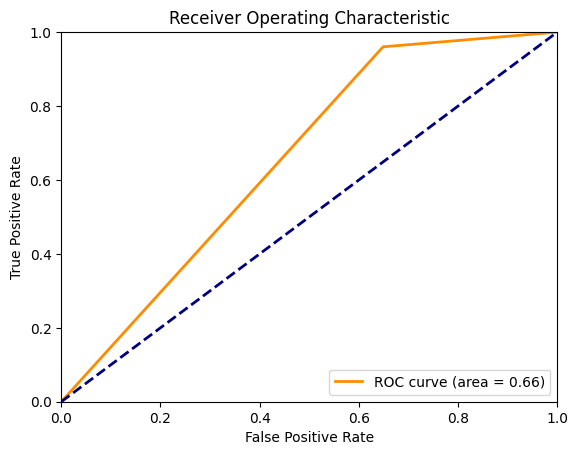

In [23]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(testy, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


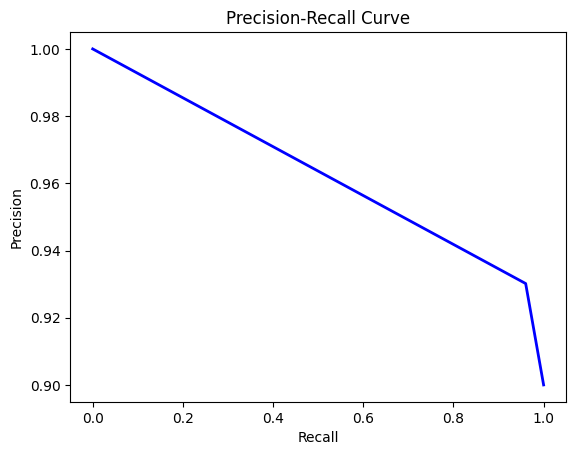

In [24]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(testy, y_pred)

plt.figure()
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()
